In [1]:
from sqlalchemy import create_engine , text
from sqlalchemy.engine import URL 
import pandas as pd

from dotenv import load_dotenv
import os

load_dotenv()

def get_engine():
    url = URL.create(
        drivername="mysql+pymysql",
        username=os.getenv("DB_USER"),
        password=os.getenv("DB_PASSWORD"),
        host=os.getenv("DB_HOST"),
        port=3306,
        database="Banking_analytics"
    )
    engine = create_engine(url)

    return engine

In [5]:
def get_query():
    query = """
        SELECT
            state,
            ROUND(AVG(annual_income), 2) AS average_income
        FROM customers
        GROUP BY state
        ORDER BY average_income DESC;
        """
    return query

In [6]:
import pandas as pd
query = get_query()
engine = get_engine()

df = pd.read_sql(text(query) , engine)
# small = df.head()
# small

,state,average_income
0,MANIPUR,1031606.38
1,NAGALAND,1029760.87
2,ANDAMAN & NICOBAR ISLANDS,977956.79
3,ORISSA,958889.95
4,CHHATTISGARH,938605.73


([0, 1, 2, 3, 4],
 [Text(0, 0, 'MANIPUR'),
  Text(1, 0, 'NAGALAND'),
  Text(2, 0, 'ANDAMAN & NICOBAR ISLANDS'),
  Text(3, 0, 'ORISSA'),
  Text(4, 0, 'CHHATTISGARH')])

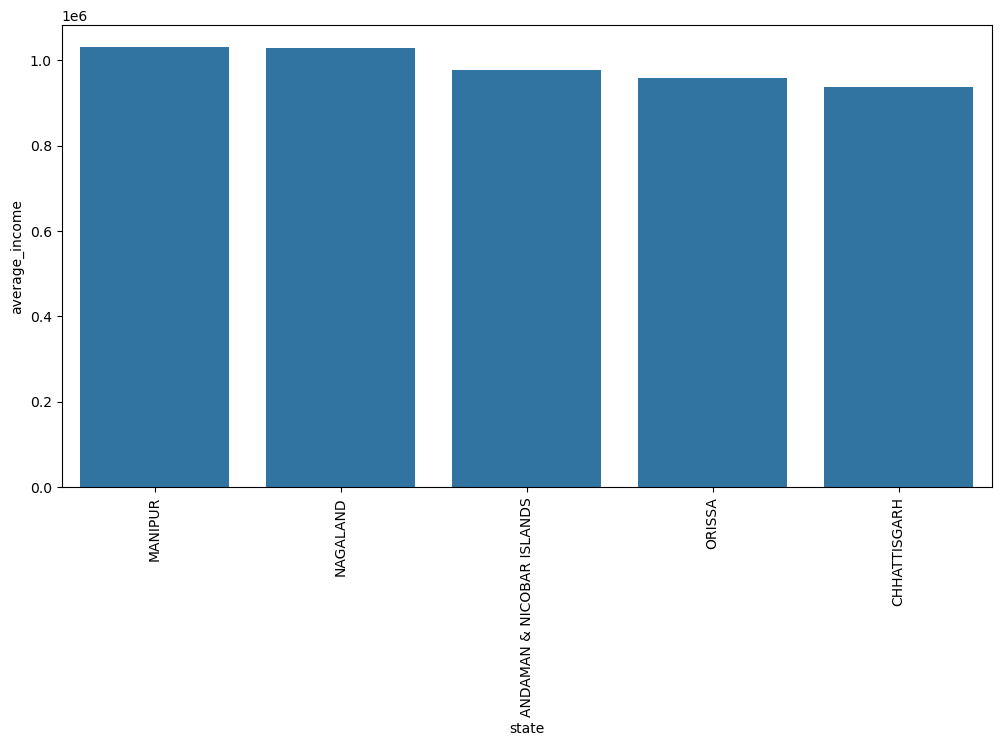

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.barplot(
    data=small,
    x="state",
    y="average_income"
)

plt.xticks(rotation=90)
# plt.show()

Text(0.5, 1.0, 'Average Income by Top 5 States')

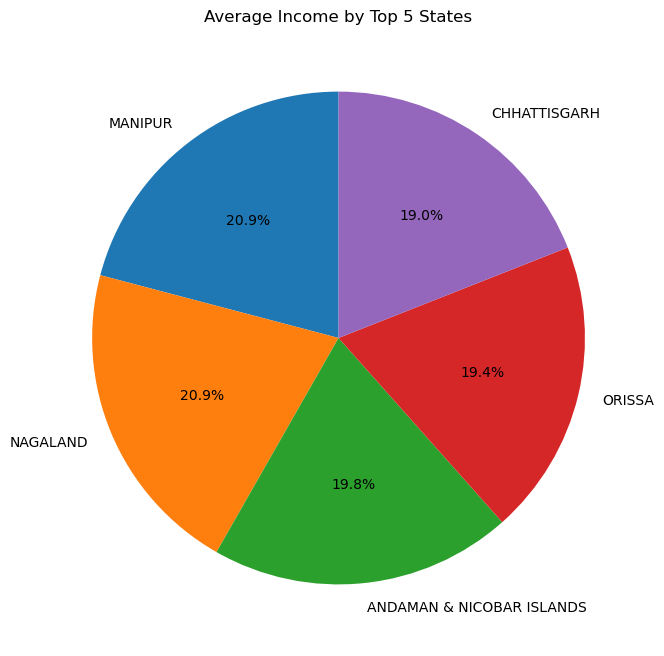

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    small["average_income"],
    labels=small["state"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Average Income by Top 5 States")
# plt.show()

----------------------------------------------


In [9]:
# new new sql query

engine = get_engine()
query = """
    SELECT ROUND(AVG(annual_income) , 2) as avg_salary,
    gender 
    FROM customers
    group by gender
    ORDER BY avg_salary DESC
    """
df  = pd.read_sql(text(query) , engine)

In [10]:
# df


,avg_salary,gender
0,900252.85,Female
1,883970.23,Male


In [11]:
# new query
query = """
    SELECT state ,
    count(*) as total_customers
    FROM customers
    group by state
    having count(*) > 5000
    order by total_customers desc
    
"""
df = pd.read_sql(text(query) , engine)

In [12]:
# df

,state,total_customers
0,UTTAR PRADESH,12747
1,WEST BENGAL,12233
2,MAHARASHTRA,8656
3,ANDHRA PRADESH,8494
4,TAMIL NADU,6722
5,MADHYA PRADESH,6514
6,GUJARAT,5932
7,RAJASTHAN,5859
8,BIHAR,5269
9,KARNATAKA,5220


In [13]:
# now we are using cases
query ="""
    SELECT 
        full_name,
        annual_income,
        
        CASE
            WHEN annual_income < 300000 THEN 'Low income'
            WHEN annual_income BETWEEN 3000000 AND 6000000 THEN 'mediem income'
            ELSE 'High income'

        END AS income_category
        
    FROM customers
    limit 20;
        """

df = pd.read_sql(text(query) ,engine)
# df

,full_name,annual_income,income_category
0,rekha bhite,1125000,High income
1,neelam merchant,367500,High income
2,bhanu yenugula,158000,Low income
3,chetan wani,2055000,High income
4,naresh namboodiri,2300000,High income
5,kuldeep das,330000,High income
6,smt kak,119000,Low income
7,mahadev nandamuri,860000,High income
8,mishri jadeja,300000,High income
9,guddiya jindal,1705000,High income


In [14]:
query ="""
    SELECT 
        CASE
            WHEN annual_income <3000000 THEN 'LOW Income'
            WHEN annual_income BETWEEN 3000000 AND 6000000 THEN 'meddium Income'
            ELSE 'High income'
        END AS income_catagory,
        COUNT(*) AS total_customer
    FROM customers

    GROUP BY income_catagory
    ORDER BY total_customer desc;
    """
df = pd.read_sql(text(query) , engine)
# df

,income_catagory,total_customer
0,LOW Income,95380
1,High income,2637
2,meddium Income,1983


In [15]:
query = """
        SELECT
            full_name,
            city,
            annual_income
        FROM customers
        WHERE city LIKE "indore%";
        """
df = pd.read_sql(text(query) ,engine)
# df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   full_name      199 non-null    object
 1   city           199 non-null    object
 2   annual_income  199 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 4.8+ KB


In [16]:
query ="""
        SELECT
            full_name,
            state,
            annual_income
        FROM customers
        WHERE state IN ("madhya pradesh" , "uttar pradesh")
            """
df = pd.read_sql(text(query) , engine)
# df

,full_name,state,annual_income
0,bhanu yenugula,UTTAR PRADESH,158000
1,kuldeep das,UTTAR PRADESH,330000
2,sangeeta choudhary,MADHYA PRADESH,167000
3,kumari ramachandran,MADHYA PRADESH,560000
4,mukesh sinha,MADHYA PRADESH,241000
...,...,...,...
19256,salim uppal,MADHYA PRADESH,123000
19257,prashant saxena,UTTAR PRADESH,350000
19258,mahfooz nadar,UTTAR PRADESH,532500
19259,ajay bardia,MADHYA PRADESH,152000


In [17]:
query = """
        SELECT
            gender,
            count(*) as total
        FROM customers
        WHERE marital_status = 'Single'
        group by gender
        """
df = pd.read_sql(text(query) , engine)
# df

,gender,total
0,Female,13032
1,Male,19713


In [18]:
query ="""
        SELECT
            full_name,
            age
        FROM customers
        WHERE age BETWEEN 70 AND 80;
        
"""
df = pd.read_sql(text(query) , engine)
# df

,full_name,age
0,neelam merchant,75
1,naresh namboodiri,70
2,sangeeta choudhary,75
3,sandeep yesuraju,77
4,dharam tahilramani,75
...,...,...
16689,deepak pohankar,78
16690,prashant saxena,74
16691,haji mallya,70
16692,yogesh sahukar,73


In [19]:
query ="""
        SELECT
            full_name,
            age,
            cibil_score
        FROM customers
        WHERE cibil_score BETWEEN 600 AND 700;
        
"""
df = pd.read_sql(text(query) , engine)
# df

,full_name,age,cibil_score
0,smt kak,21,646
1,mishri jadeja,28,685
2,sandeep yesuraju,77,674
3,yashin narang,40,624
4,dharam tahilramani,75,604
...,...,...,...
27743,mahfooz nadar,62,647
27744,mohd shishodia,21,655
27745,rajesh chandavarkar,21,649
27746,rashmi vijayrania,20,680


In [20]:
query ="""
        SELECT
            DISTINCT state
        FROM customers
        
"""
df = pd.read_sql(text(query) , engine)
# df

,state
0,WEST BENGAL
1,NCT OF DELHI
2,UTTAR PRADESH
3,TAMIL NADU
4,MAHARASHTRA
5,GUJARAT
6,BIHAR
7,RAJASTHAN
8,MADHYA PRADESH
9,HARYANA


In [21]:
# 10 (pehla) = kitni rows skip karni hain
# 10 (doosra) = kitni rows dikhani hain
query ="""
        SELECT
            full_name,
            annual_income
            
        FROM customers
        LIMIT 99994, 10;
        
"""
df = pd.read_sql(text(query) , engine)
# df

,full_name,annual_income
0,ajay bardia,152000
1,rana wankhede,372500
2,vaishali marwaha,330000
3,sonu tandel,815000
4,avtar wagle,485000
5,bandana malusare,1165000


In [22]:
query ="""
        SELECT
            full_name,
            cibil_score,
            account_balance
        FROM customers
        ORDER BY cibil_score ASC , account_balance  DESC
        limit 20;
        
"""
df = pd.read_sql(text(query) ,engine)
# df


,full_name,cibil_score,account_balance
0,satendra tayde,300,29500000
1,mazhar gill,300,29200000
2,khusbu nalamolu,300,4830000
3,gopi dusanj,300,4790000
4,harish somaiya,300,2300000
5,tarun hooda,300,1810000
6,bhoop amrutham,300,1590000
7,vipul tendulkar,300,1310000
8,virender talsania,300,940000
9,gaurav waghe,300,845000


In [23]:
query ="""
        SELECT
            full_name,
            annual_income
        FROM customers
        WHERE annual_income >
        (
            SELECT AVG(annual_income)
            FROM customers
        )
        ORDER BY annual_income DESC;
                
"""
df = pd.read_sql(text(query) ,engine)
# df

,full_name,annual_income
0,tosif jobanputra,10000000
1,balmiki hadapsar,10000000
2,sahil rao,10000000
3,preeti gautam,10000000
4,uma duddala,10000000
...,...,...
25077,om koganti,895000
25078,sk gadekar,895000
25079,gargi dasgupta,895000
25080,hemanshu tirodkar,895000


In [24]:
query ="""
        SELECT
            full_name,
            annual_income
        FROM customers
        WHERE annual_income > (
        SELECT
            AVG(annual_income)
        FROM customers
        )
        ORDER BY annual_income DESC;
                
"""
df = pd.read_sql(text(query) ,engine)
# df

,full_name,annual_income
0,tosif jobanputra,10000000
1,balmiki hadapsar,10000000
2,sahil rao,10000000
3,preeti gautam,10000000
4,uma duddala,10000000
...,...,...
25077,om koganti,895000
25078,sk gadekar,895000
25079,gargi dasgupta,895000
25080,hemanshu tirodkar,895000


In [25]:
query = """
        SELECT
            full_name,
            cibil_score
        FROM customers
        WHERE cibil_score = (
        SELECT 
            MAX(cibil_score)
            FROM customers
        )    
        """
df = pd.read_sql(text(query) ,engine)
# df

,full_name,cibil_score
0,shivani modi,900
1,sidharath apdev,900
2,roshni saklani,900
3,veer dwivedi,900
4,sushil mehta,900
...,...,...
92,sapna walale,900
93,kiran upadhye,900
94,smt verma,900
95,salim sehwag,900


--------------------------------------------------------

<h1> now we using JOINS</h1>

In [6]:
engine = get_engine()
query = """
SELECT
    c.customer_id,
    c.full_name,
    c.gender,
    a.account_number,
    a.account_type,
    a.account_balance

FROM customers c
INNER JOIN accounts a
ON c.customer_id = a.customer_id;
"""

df = pd.read_sql(text(query), engine)
df.head()

,customer_id,full_name,gender,account_number,account_type,account_balance
0,1,rekha bhite,Female,679846567537,Saving,3860000.0
1,2,neelam merchant,Female,712378913442,Saving,18500.0
2,3,bhanu yenugula,Male,500989646859,Saving,133000.0
3,4,chetan wani,Male,693285470455,Saving,3000.0
4,5,naresh namboodiri,Male,648513229632,Saving,83000.0


In [7]:
# left join
engine = get_engine()
query = """
SELECT
    c.customer_id,
    c.full_name,
    c.gender,
    a.account_number,
    a.account_type,
    a.account_balance

FROM customers c
LEFT JOIN accounts a
ON c.customer_id = a.customer_id;
"""

df = pd.read_sql(text(query), engine)
df.head()
# same output as inner join will come becouse in the right table not contain null value 

,customer_id,full_name,gender,account_number,account_type,account_balance
0,1,rekha bhite,Female,679846567537,Saving,3860000.0
1,2,neelam merchant,Female,712378913442,Saving,18500.0
2,3,bhanu yenugula,Male,500989646859,Saving,133000.0
3,4,chetan wani,Male,693285470455,Saving,3000.0
4,5,naresh namboodiri,Male,648513229632,Saving,83000.0


In [10]:
# right join
# left join
engine = get_engine()
query = """
SELECT
    c.customer_id,
    c.full_name,
    a.account_number,
    a.account_balance

FROM customers c

RIGHT JOIN accounts a
ON c.customer_id = a.customer_id;
"""

df = pd.read_sql(text(query), engine)
df.head()
# same output as inner join will come becouse in the LEFT table not contain null value 

,customer_id,full_name,account_number,account_balance
0,1,rekha bhite,679846567537,3860000.0
1,2,neelam merchant,712378913442,18500.0
2,3,bhanu yenugula,500989646859,133000.0
3,4,chetan wani,693285470455,3000.0
4,5,naresh namboodiri,648513229632,83000.0


In [2]:
    url = URL.create(
        drivername="mysql+pymysql",
        username=os.getenv("DB_USER"),
        password=os.getenv("DB_PASSWORD"),
        host=os.getenv("DB_HOST"),
        port=3306,
        database="Banking_analytics"
    )
    engine = create_engine(url)


In [11]:
query="""
        SELECT COUNT(*) AS total_customer
        from customers;
        """
df = pd.read_sql(text(query) ,engine)
df

,total_customer
0,100000


In [13]:
query="""
        SELECT COUNT(loan_id) AS total_loan
        from loans;
        """
df = pd.read_sql(text(query) ,engine)
df

,total_loan
0,100000


In [14]:
query="""
        SELECT sum(loan_amount) as total_ammount
        from loans
        """
df = pd.read_sql(text(query) ,engine)
df

,total_ammount
0,2.224659e+11


In [16]:
query="""
        select round(avg(loan_amount) ,2) as avg
        from loans;
        """
df = pd.read_sql(text(query) ,engine)
df

,avg
0,2224659.28


In [17]:
query="""
        select max(loan_amount) as max
        from loans;
        """
df = pd.read_sql(text(query) ,engine)
df

,max
0,9999808.0


In [19]:
query="""
        select min(loan_amount) as min
        from loans;
        """
df = pd.read_sql(text(query) ,engine)
df

,min
0,50004.0


In [21]:
query="""
        select round(avg(account_balance),2) as avg_baalnce
        from accounts;
        """
df = pd.read_sql(text(query) ,engine)
df

,avg_baalnce
0,1824103.33


In [24]:
query="""
        select round(sum(account_balance),2) as total_balance
        from accounts;
        """
df = pd.read_sql(text(query) ,engine)
df

,total_balance
0,1.824103e+11


In [26]:
query="""
        select account_type , count(*) as total_acounts
        from accounts
        group by account_type;
        """
df = pd.read_sql(text(query) ,engine)
df

,account_type,total_acounts
0,Saving,70097
1,Current,19883
2,Salary,10020


In [27]:
query="""
        select loan_status , count(*) as total_loans
        from loans
        group by loan_status;
        """
df = pd.read_sql(text(query) ,engine)
df

,loan_status,total_loans
0,Rejected,19530
1,Pending,39321
2,Approved,41149


In [31]:
query="""
        select loan_type , count(*) as total_loans
        from loans
        group by loan_type;
        """
df = pd.read_sql(text(query) ,engine)
df

,loan_type,total_loans
0,Personal Loan,34778
1,Home Loan,25059
2,Business Loan,9908
3,Car Loan,20043
4,Education Loan,10212


In [36]:
query="""
        select transaction_mode , count(*) as total
        from transactions
        group by transaction_mode
        order by total desc;
        """
df = pd.read_sql(text(query) ,engine)
df

,transaction_mode,total
0,UPI,220772
1,Debit Card,157481
2,NEFT,138945
3,IMPS,82280
4,Credit Card,78329
5,Cash Deposit,44861
6,ATM,26356


In [40]:
query="""
        select customer_id , account_balance
        from customers
        order by account_balance desc
        limit 10;
        """
df = pd.read_sql(text(query) ,engine)
df

,customer_id,account_balance
0,76164,50000000
1,25361,50000000
2,11526,50000000
3,19832,49950000
4,28257,49950000
5,62500,49950000
6,69378,49950000
7,42654,49950000
8,32861,49900000
9,52032,49900000


In [43]:
query="""
        select customer_id , loan_amount
        from loans
        order by loan_amount desc
        limit 10;
        """
df = pd.read_sql(text(query) ,engine)
df

,customer_id,loan_amount
0,31694,9999808.0
1,2764,9999243.0
2,49198,9998794.0
3,95733,9998630.0
4,99713,9998531.0
5,20812,9997912.0
6,37697,9997648.0
7,61012,9997027.0
8,883,9996960.0
9,13460,9996001.0


In [47]:
query="""
        SELECT account_id, amount
        FROM transactions
        ORDER BY amount DESC
        LIMIT 10;
        """
df = pd.read_sql(text(query) ,engine)
df

,account_id,amount
0,59790,100000.0
1,3766,99999.0
2,93356,99998.0
3,99208,99997.0
4,12492,99997.0
5,35062,99996.0
6,74543,99995.0
7,40771,99995.0
8,95855,99995.0
9,13009,99994.0


In [48]:
query="""
        select count(account_id) as ttoal
        from transactions;
        """
df = pd.read_sql(text(query) ,engine)
df

,ttoal
0,749024


In [50]:
query="""
        select account_type , round(avg(account_balance),2) as avg
        from accounts
        group by account_type;
        """
df = pd.read_sql(text(query) ,engine)
df

,account_type,avg
0,Saving,1787629.91
1,Current,1895461.47
2,Salary,1937662.52


In [51]:
query="""
        select loan_type , round(sum(loan_amount),2) as total_loan
        from loans
        group by loan_type;
        """
df = pd.read_sql(text(query) ,engine)
df

,loan_type,total_loan
0,Personal Loan,1.835039e+10
1,Home Loan,1.378340e+11
2,Business Loan,2.717496e+10
3,Car Loan,2.309139e+10
4,Education Loan,1.601517e+10


In [56]:
query="""
        select c.customer_id,
        c.full_name,
        a.account_balance
        from customers c
        inner join accounts a
        ON c.customer_id = a.customer_id
        order by a.account_balance desc
        limit 20;
        """
df = pd.read_sql(text(query) ,engine)
df

,customer_id,full_name,account_balance
0,76164,nemsi amrutham,50000000.0
1,25361,tisar jadi,50000000.0
2,11526,babloo moitra,50000000.0
3,62500,shamshad mandlekar,49950000.0
4,69378,ashok thakran,49950000.0
5,42654,priya anand,49950000.0
6,28257,bhagat janmeja,49950000.0
7,19832,laxmi fernandez,49950000.0
8,13711,deepak tambke,49900000.0
9,72004,mithlesh chaudhary,49900000.0


In [60]:
query="""
        select 
        c.customer_id,
        # c.full_name,
        l.loan_type,
        l.loan_amount
        from customers c
        join  loans l
        on c.customer_id = l.customer_id;
        """
df = pd.read_sql(text(query) ,engine)
df

,customer_id,loan_type,loan_amount
0,89654,Personal Loan,943425.0
1,39204,Home Loan,3825262.0
2,19757,Home Loan,3436855.0
3,71881,Car Loan,1258584.0
4,13918,Car Loan,1268847.0
...,...,...,...
99995,19429,Personal Loan,210470.0
99996,5033,Education Loan,1900580.0
99997,39902,Personal Loan,429101.0
99998,27620,Car Loan,328019.0


In [66]:
query="""
        select 
        c.customer_id,
        c.full_name,
        t.transaction_type,
        t.amount
        from customers c
        inner join transactions t
        on c.customer_id = t.account_id
        limit 10;
        """
df = pd.read_sql(text(query) ,engine)
df

,customer_id,full_name,transaction_type,amount
0,1,rekha bhite,Debit,7281.0
1,1,rekha bhite,Debit,45591.0
2,1,rekha bhite,Debit,39620.0
3,1,rekha bhite,Debit,46652.0
4,1,rekha bhite,Credit,21607.0
5,1,rekha bhite,Debit,47465.0
6,2,neelam merchant,Credit,82624.0
7,2,neelam merchant,Debit,33595.0
8,2,neelam merchant,Debit,17501.0
9,2,neelam merchant,Debit,1870.0


In [71]:
query="""
        select 
        c.customer_id,
        # c.full_name,
        sum(t.amount) as total_transactions
        from transactions t
        join customers c
        on c.customer_id = t.account_id 
        group by c.customer_id
        limit 10;
        """
df = pd.read_sql(text(query) ,engine)
df

,customer_id,total_transactions
0,1,208216.0
1,2,162566.0
2,3,123938.0
3,4,108620.0
4,5,323045.0
5,6,306644.0
6,7,226273.0
7,8,206392.0
8,9,338491.0
9,10,77773.0


In [83]:
query="""
        select 
        c.customer_id,
        count(l.loan_id) as total_loans
        from customers c
        join loans l
        on c.customer_id = l.customer_id
        group by c.customer_id
        having total_loans >=1
        
        limit 10;
        """
df = pd.read_sql(text(query) ,engine)
df

,customer_id,total_loans
0,1,1
1,2,1
2,3,1
3,4,1
4,5,1
...,...,...
99995,99996,1
99996,99997,1
99997,99998,1
99998,99999,1


In [89]:
query="""
        select 
       customer_id,
       full_name,
       account_balance
       from customers 
       where account_balance > 
       (
       select avg(account_balance)
       from customers
       )
        """
df = pd.read_sql(text(query) ,engine)
df

,customer_id,full_name,account_balance
0,1,rekha bhite,3860000
1,9,mishri jadeja,3660000
2,15,dharam tahilramani,44250000
3,21,dev karkera,2010000
4,27,rakesh bhanot,3560000
...,...,...,...
12787,99911,md. swamy,13700000
12788,99912,sonu patni,3620000
12789,99941,jyoti tamang,9400000
12790,99974,renu dandekar,3460000


In [7]:
query="""
        SELECT
            customer_id,
            account_balance,
            CASE
                WHEN account_balance >= 500000 THEN 'High'
                WHEN account_balance >= 100000 THEN 'Medium'
                ELSE 'Low'
            END AS Balance_Category
    FROM accounts;
        """
df = pd.read_sql(text(query) ,engine)
df

,customer_id,account_balance,Balance_Category
0,1,3860000.0,High
1,2,18500.0,Low
2,3,133000.0,Medium
3,4,3000.0,Low
4,5,83000.0,Low
...,...,...,...
99995,99996,52000.0,Low
99996,99997,1430000.0,High
99997,99998,24500.0,Low
99998,99999,50000.0,Low


In [9]:
query="""
        select 
        case
            when account_balance >= 500000 then "high"
            when account_balance >=100000 then "medium"
            else "low"
        end as balance_catagory,
        count(*) as total_cata
        from accounts
        group by balance_catagory;
        """
df = pd.read_sql(text(query) ,engine)
df

,balance_catagory,total_cata
0,high,27350
1,low,44970
2,medium,27680


In [11]:
query="""
        select 
            c.customer_id,
            c.full_name,
            l.loan_type
            from customers c
            left join loans l
            on c.customer_id = l.customer_id;
        """
df = pd.read_sql(text(query) ,engine)
df

,customer_id,full_name,loan_type
0,1,rekha bhite,Personal Loan
1,2,neelam merchant,Personal Loan
2,3,bhanu yenugula,Home Loan
3,4,chetan wani,Home Loan
4,5,naresh namboodiri,Personal Loan
...,...,...,...
99995,99996,rana wankhede,Education Loan
99996,99997,vaishali marwaha,Personal Loan
99997,99998,sonu tandel,Home Loan
99998,99999,avtar wagle,Home Loan


In [12]:
query="""
        select 
        c.customer_id,
        c.full_name
        from customers c
        left join loans l
        on c.customer_id = l.customer_id
        where l.customer_id is null;
        """
df = pd.read_sql(text(query) ,engine)
df

,customer_id,full_name


In [19]:
query="""
        select 
            customer_id,
            account_balance,
            full_name,
            ROW_NUMBER() OVER (ORDER BY account_balance desc) as row_num
            from customers
            limit 10;
        """
df = pd.read_sql(text(query) ,engine)
df

,customer_id,account_balance,full_name,row_num
0,76164,50000000,nemsi amrutham,1
1,25361,50000000,tisar jadi,2
2,11526,50000000,babloo moitra,3
3,19832,49950000,laxmi fernandez,4
4,28257,49950000,bhagat janmeja,5
5,69378,49950000,ashok thakran,6
6,42654,49950000,priya anand,7
7,62500,49950000,shamshad mandlekar,8
8,60146,49900000,harish phogat,9
9,72004,49900000,mithlesh chaudhary,10


In [20]:
query="""
        select 
        customer_id,
        account_balance,
        rank() over (order by account_balance desc) as customer_rank
        from accounts
        """
df = pd.read_sql(text(query) ,engine)
df

,customer_id,account_balance,customer_rank
0,76164,50000000.0,1
1,25361,50000000.0,1
2,11526,50000000.0,1
3,62500,49950000.0,4
4,69378,49950000.0,4
...,...,...,...
99995,49428,1000.0,99660
99996,49532,1000.0,99660
99997,50067,1000.0,99660
99998,51616,1000.0,99660


In [23]:
query="""
        select 
        customer_id,
        account_balance,
        dense_rank() over (order by account_balance desc) as customer_rank
        from accounts
        limit 10;
        """
df = pd.read_sql(text(query) ,engine)
df

,customer_id,account_balance,customer_rank
0,76164,50000000.0,1
1,25361,50000000.0,1
2,11526,50000000.0,1
3,62500,49950000.0,2
4,69378,49950000.0,2
5,42654,49950000.0,2
6,28257,49950000.0,2
7,19832,49950000.0,2
8,13711,49900000.0,3
9,72004,49900000.0,3
